# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `RL_results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("RL_results.tsv", sep="\t")
df["total_reward"] = pd.to_numeric(df["Post_RL_total_reward"], errors="coerce")
df["status"] = df["status(keep/discard)"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 51
Columns: ['commit', 'Post_RL_total_reward', 'numerical_reward', 'format_reward', 'status(keep/discard)', 'description', 'total_reward', 'status']


,commit,Post_RL_total_reward,numerical_reward,format_reward,status(keep/discard),description,total_reward,status
0,6b61ed0,136.71875,49.218750,87.500000,keep,"baseline default parameters (RANK=64, ALPHA=64...",136.718750,KEEP
1,43994df,136.71875,48.437500,88.281250,discard,"LR=5e-6, BETA=0.05 - equal reward to baseline ...",136.718750,DISCARD
2,add5d0e,119.140625,26.171875,92.968750,discard,"RANK=128, ALPHA=128 - rank too high, degraded ...",119.140625,DISCARD
3,c08818a,139.453125,51.171875,88.281250,keep,"RANK=16, ALPHA=32 - improved accuracy to 51.17...",139.453125,KEEP
4,029cad4,140.625,50.390625,90.234375,keep,BETA=0.05 with RANK=16 - format accuracy reach...,140.625000,KEEP
5,42004c8,147.65625,54.296875,93.359375,keep,rollout TEMPERATURE=0.7 - accuracy jumped to 5...,147.656250,KEEP
6,20e1664,145.3125,58.203125,87.109375,discard,"TEMP=0.6, TOP_P=0.95 - highest numerical accur...",145.312500,DISCARD
7,418438a,143.75,52.343750,91.406250,discard,"B2=0.999, WEIGHT_DECAY=0.01 - lower total rewa...",143.750000,DISCARD
8,2b8de7a,139.84375,47.265625,92.578125,discard,"MAX_GRAD_NORM=0.3, EPSILON=0.15 - lower reward...",139.843750,DISCARD
9,3cd61a1,139.0625,51.171875,87.890625,discard,TEMP=0.65 - lower total reward (139.06) than E...,139.062500,DISCARD


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    46
KEEP        5

Keep rate: 5/51 = 9.8%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    total_reward = row["total_reward"]
    desc = row["description"]
    print(f"  #{i:3d}  total_reward={total_reward:.6f}  {desc}")

KEPT experiments (5 total):

  #  0  total_reward=136.718750  baseline default parameters (RANK=64, ALPHA=64, LR=3e-6, AdamW warmup cosine)
  #  3  total_reward=139.453125  RANK=16, ALPHA=32 - improved accuracy to 51.17% and total reward to 139.45
  #  4  total_reward=140.625000  BETA=0.05 with RANK=16 - format accuracy reached 90.23%, total reward 140.625
  #  5  total_reward=147.656250  rollout TEMPERATURE=0.7 - accuracy jumped to 54.30%, format to 93.36%, total reward 147.66
  # 44  total_reward=148.828125  MAX_GRAD_NORM=0.15 - NEW BEST! format accuracy jumped to 96.09%, total reward 148.828125!


## Total Over Time

Track how the best (kept) total reward evolves as experiments progress. The running maximum shows the "frontier" -- the best result achieved so far.

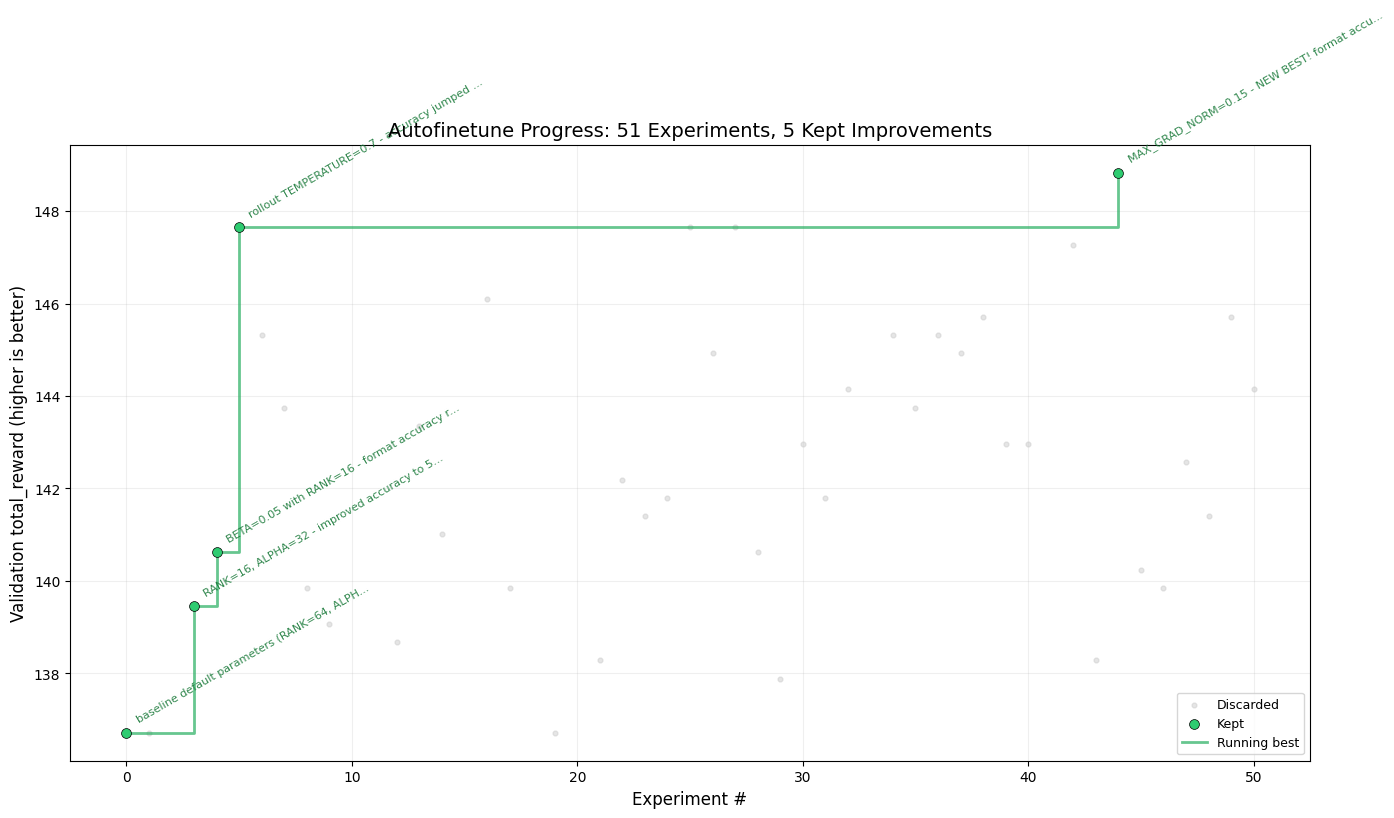

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_total_reward = valid.loc[0, "total_reward"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["total_reward"] >= baseline_total_reward - 0.0005]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["total_reward"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["total_reward"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_total_reward = valid.loc[kept_mask, "total_reward"]
running_max = kept_total_reward.cummax() # Changed to cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, total_reward in zip(kept_idx, kept_total_reward):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, total_reward),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")
    
# Fixed fallback variable from baseline_bpb to baseline_total_reward
best = running_max.iloc[-1] if len(running_max) > 0 else baseline_total_reward
n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])

ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation total_reward (higher is better)", fontsize=12) # Updated label
ax.set_title(f"Autofinetune Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="lower right", fontsize=9) # Moved to lower right so the rising line doesn't collide with it
ax.grid(True, alpha=0.2)

# Y-axis: from just below baseline to just above best
margin = (best - baseline_total_reward) * 0.15
# Added absolute value fallback just in case best == baseline